# Notebook 3: Fraud Prediction Models, Evaluation and Threshold Analysis

**Project**: E-Commerce Fraud Detection Analysis  
**Subject**: Fraud Detection Analysis (MBA Data Science)  
**Dataset**: IEEE-CIS Fraud Detection Dataset  

---

## 1. Executive Summary & Objectives
Trains 4 supervised classification models (*Logistic Regression, Decision Tree, Random Forest, HistGradientBoosting*) on train-imputed 11 features and evaluates performance against a Majority-Class Baseline.


In [1]:
# Imports, Setup & Modeling Functions
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve
)

proc_dir = 'data/processed'
fig_dir = 'outputs/figures'
tbl_dir = 'outputs/tables'
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tbl_dir, exist_ok=True)

X_train = pd.read_parquet(os.path.join(proc_dir, 'X_train.parquet'))
X_val = pd.read_parquet(os.path.join(proc_dir, 'X_val.parquet'))
y_train = np.load(os.path.join(proc_dir, 'y_train.npy'))
y_val = np.load(os.path.join(proc_dir, 'y_val.npy'))

def build_models(random_state=42):
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=random_state, solver='lbfgs', C=0.1))
        ]),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', min_samples_leaf=30, random_state=random_state),
        'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, class_weight='balanced_subsample', min_samples_leaf=15, random_state=random_state, n_jobs=-1),
        'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_leaf_nodes=63, min_samples_leaf=30, l2_regularization=1.0, random_state=random_state, class_weight='balanced')
    }

def evaluate_majority_baseline(y_true):
    y_pred = np.zeros_like(y_true)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tn + tp) / (tn + fp + fn + tp)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {
        'Model': 'Majority-Class Baseline',
        'Accuracy': f"{acc*100:.2f}%",
        'Precision': round(float(prec), 4),
        'Recall': round(float(rec), 4),
        'F1-Score': round(float(f1), 4),
        'ROC-AUC': 0.5000,
        'PR-AUC': round(float(np.mean(y_true)), 4),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)
    }

def evaluate_predictions(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tn + tp) / (tn + fp + fn + tp)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    return {
        'Accuracy': f"{acc*100:.2f}%",
        'Precision': round(float(prec), 4),
        'Recall': round(float(rec), 4),
        'F1-Score': round(float(f1), 4),
        'ROC-AUC': round(float(roc_auc), 4),
        'PR-AUC': round(float(pr_auc), 4),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)
    }

def evaluate_thresholds(y_true, y_prob, thresholds=[0.30, 0.40, 0.50, 0.60, 0.70]):
    records = []
    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        records.append({
            'Threshold': th,
            'Precision': round(float(prec), 4),
            'Recall': round(float(rec), 4),
            'F1-Score': round(float(f1), 4)
        })
    return pd.DataFrame(records)

def plot_confusion_matrix_fig(cm, model_name, save_path):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legitimate (0)', 'Fraud (1)'], yticklabels=['Legitimate (0)', 'Fraud (1)'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def plot_combined_pr_curve(results_dict, save_path):
    plt.figure(figsize=(8, 6))
    for name, res in results_dict.items():
        precisions, recalls, _ = precision_recall_curve(res['y_true'], res['y_prob'])
        pr_auc_val = res['metrics']['PR-AUC']
        plt.plot(recalls, precisions, label=f'{name} (PR-AUC = {pr_auc_val:.4f})', linewidth=2)
    first_key = list(results_dict.keys())[0]
    pos_prop = np.mean(results_dict[first_key]['y_true'])
    plt.plot([0, 1], [pos_prop, pos_prop], 'r--', label=f'Baseline (Fraud Rate = {pos_prop:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall (True Positive Rate)')
    plt.ylabel('Precision (Positive Predictive Value)')
    plt.title('Precision-Recall (PR) Curves', fontsize=13, fontweight='bold', pad=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def plot_combined_roc_curve(results_dict, save_path):
    plt.figure(figsize=(8, 6))
    for name, res in results_dict.items():
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
        auc_val = res['metrics']['ROC-AUC']
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.5000)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=13, fontweight='bold', pad=12)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def plot_threshold_tradeoff(thresh_df, model_name, save_path):
    plt.figure(figsize=(8, 5))
    plt.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision', linewidth=2)
    plt.plot(thresh_df['Threshold'], thresh_df['Recall'], 'g-s', label='Recall', linewidth=2)
    plt.plot(thresh_df['Threshold'], thresh_df['F1-Score'], 'r-^', label='F1-Score', linewidth=2)
    plt.xlabel('Classification Decision Threshold')
    plt.ylabel('Score')
    plt.title(f'Decision Threshold Trade-off Analysis ({model_name})', fontsize=12, fontweight='bold', pad=10)
    plt.legend(loc='center right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def plot_feature_importance(importances, feature_names, save_path, top_n=15):
    imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=imp_series.values, y=imp_series.index, hue=imp_series.index, palette='crest', legend=False)
    plt.title(f'Top {top_n} Model-Important Features (Random Forest)', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('Mean Decrease in Impurity (Gini Importance)')
    plt.ylabel('Feature Name')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


## 2. Modeling Feature Selection & Train-Fitted Imputation


In [2]:
feature_cols = [
    'TransactionAmt',
    'ProductCD',
    'card4',
    'card6',
    'P_emaildomain',
    'R_emaildomain',
    'transaction_hour',
    'log_TransactionAmt',
    'missing_identity_flag',
    'missing_count_row',
    'email_match_flag'
]

missing_features = [
    col for col in feature_cols
    if col not in X_train.columns or col not in X_val.columns
]
if missing_features:
    raise ValueError(f'Required modeling features are missing: {missing_features}')

X_train_sub = X_train[feature_cols].copy()
X_val_sub = X_val[feature_cols].copy()

categorical_features = [
    col for col in ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
    if col in feature_cols
]
numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

X_train_model = X_train_sub.copy()
X_val_model = X_val_sub.copy()

numeric_imputer = SimpleImputer(strategy='median')
X_train_model[numeric_features] = numeric_imputer.fit_transform(X_train_model[numeric_features])
X_val_model[numeric_features] = numeric_imputer.transform(X_val_model[numeric_features])

categorical_imputer = SimpleImputer(strategy='most_frequent')
if categorical_features:
    X_train_model[categorical_features] = categorical_imputer.fit_transform(X_train_model[categorical_features])
    X_val_model[categorical_features] = categorical_imputer.transform(X_val_model[categorical_features])
    
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_model[categorical_features] = encoder.fit_transform(X_train_model[categorical_features])
    X_val_model[categorical_features] = encoder.transform(X_val_model[categorical_features])

print(f'Selected Features ({len(feature_cols)}): {feature_cols}')
print(f'Numeric Features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical Features ({len(categorical_features)}): {categorical_features}')


Selected Features (11): ['TransactionAmt', 'ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'transaction_hour', 'log_TransactionAmt', 'missing_identity_flag', 'missing_count_row', 'email_match_flag']
Numeric Features (6): ['TransactionAmt', 'transaction_hour', 'log_TransactionAmt', 'missing_identity_flag', 'missing_count_row', 'email_match_flag']
Categorical Features (5): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']


## 3. Baseline & ML Model Training


In [3]:
baseline_metrics = evaluate_majority_baseline(y_val)
print('=== MAJORITY-CLASS BASELINE BENCHMARK ===')
for k, v in baseline_metrics.items():
    print(f'{k}: {v}')

models = build_models()
results = {}
eval_records = [baseline_metrics]

for name, model in models.items():
    print(f'Training {name}...', flush=True)
    model.fit(X_train_model, y_train)
    y_prob = model.predict_proba(X_val_model)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)
    metrics = evaluate_predictions(y_val, y_pred, y_prob)
    results[name] = {'model': model, 'y_prob': y_prob, 'y_pred': y_pred, 'y_true': y_val, 'metrics': metrics}
    rec = {'Model': name}
    rec.update(metrics)
    eval_records.append(rec)
    print(f'-> {name} | Accuracy: {metrics["Accuracy"]} | PR-AUC: {metrics["PR-AUC"]} | ROC-AUC: {metrics["ROC-AUC"]}')

comp_df = pd.DataFrame(eval_records)
comp_df.to_csv(os.path.join(tbl_dir, 'model_comparison.csv'), index=False)
print('\n=== FINAL MODEL COMPARISON TABLE ===')
print(comp_df.to_string(index=False))


=== MAJORITY-CLASS BASELINE BENCHMARK ===
Model: Majority-Class Baseline
Accuracy: 96.56%
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
ROC-AUC: 0.5
PR-AUC: 0.0344
TN: 114044
FP: 0
FN: 4064
TP: 0
Training Logistic Regression...
-> Logistic Regression | Accuracy: 75.75% | PR-AUC: 0.1167 | ROC-AUC: 0.7333
Training Decision Tree...
-> Decision Tree | Accuracy: 80.07% | PR-AUC: 0.1668 | ROC-AUC: 0.7627
Training Random Forest...
-> Random Forest | Accuracy: 86.10% | PR-AUC: 0.2012 | ROC-AUC: 0.7915
Training HistGradientBoosting...
-> HistGradientBoosting | Accuracy: 82.64% | PR-AUC: 0.2252 | ROC-AUC: 0.8012

=== FINAL MODEL COMPARISON TABLE ===
                  Model Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC     TN    FP   FN   TP
Majority-Class Baseline   96.56%     0.0000  0.0000    0.0000   0.5000  0.0344 114044     0 4064    0
    Logistic Regression   75.75%     0.0822  0.5950    0.1444   0.7333  0.1167  87046 26998 1646 2418
          Decision Tree   80.07%     0.1005  0.6026

## 4. Visual Evaluations (Confusion Matrices, PR/ROC Curves)


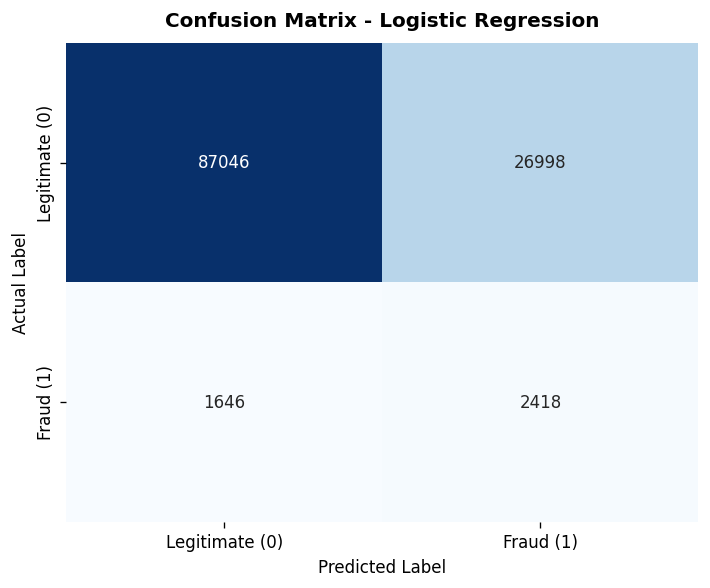

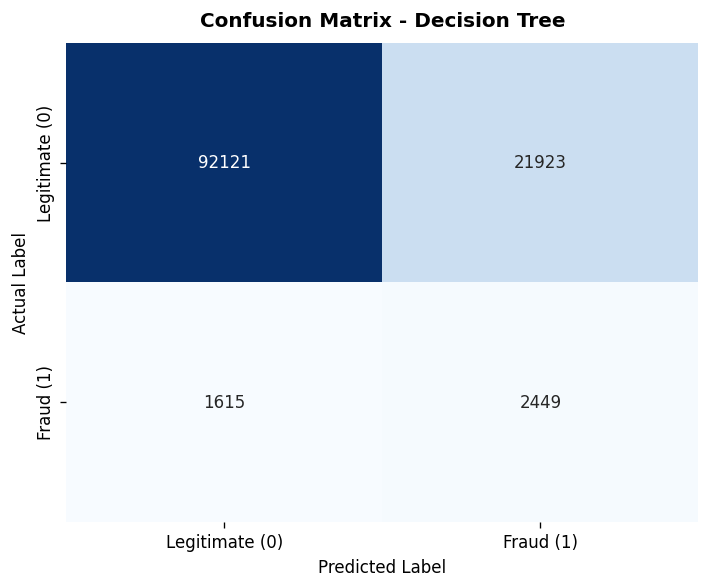

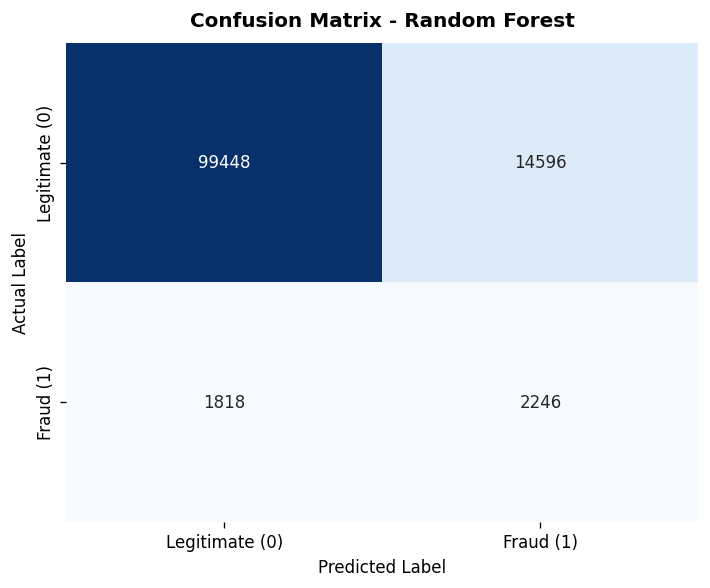

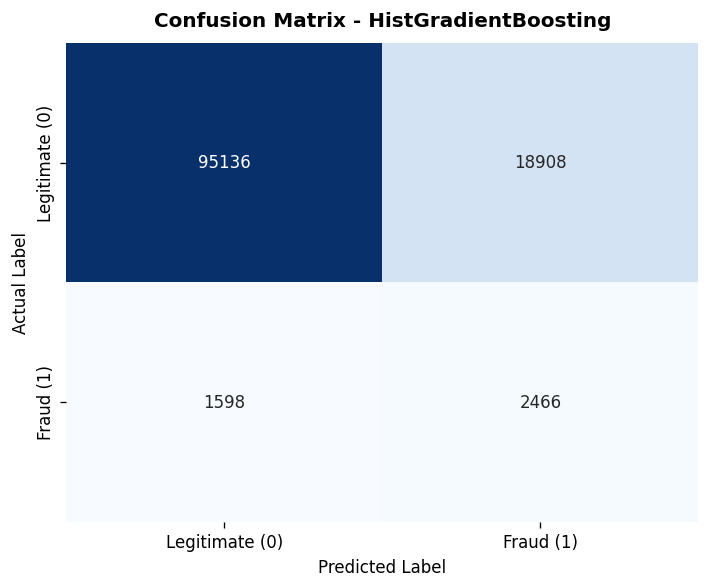

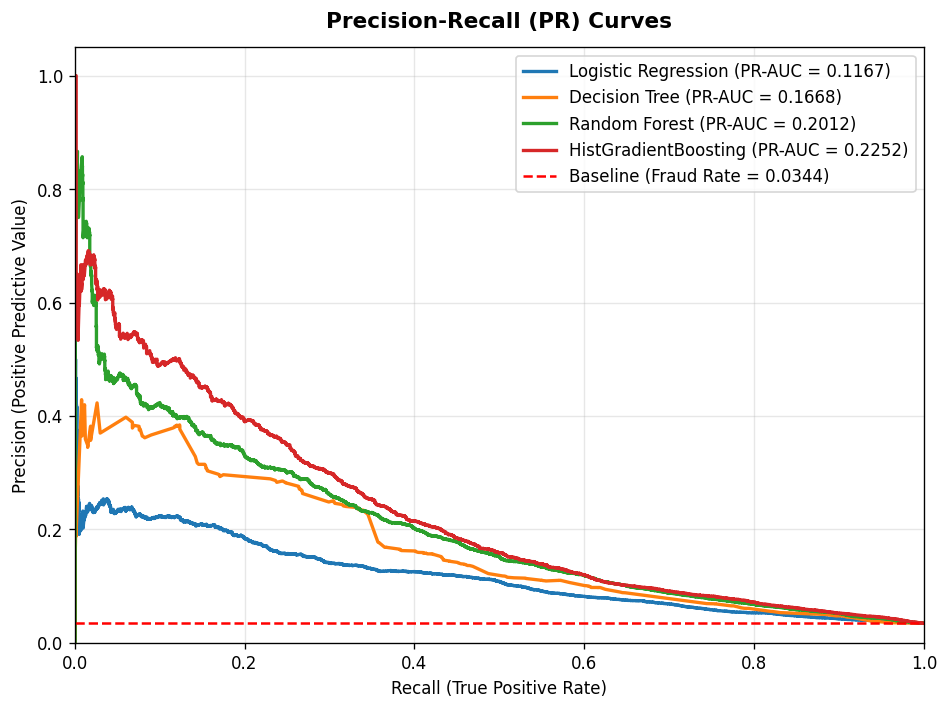

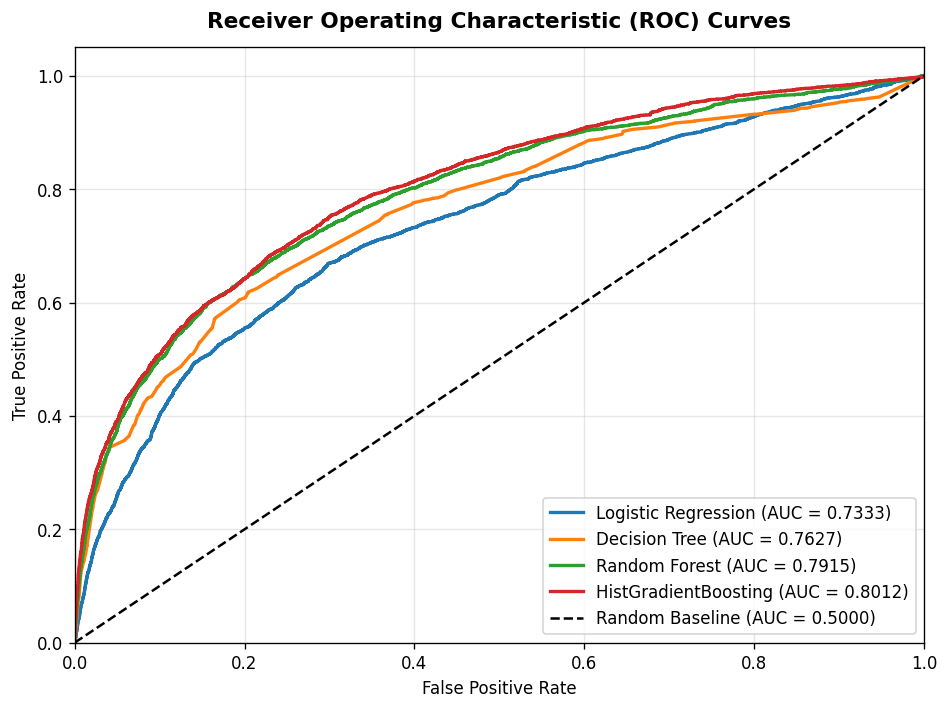

In [4]:
for name, res in results.items():
    cm = confusion_matrix(y_val, res['y_pred'])
    plot_confusion_matrix_fig(cm, name, os.path.join(fig_dir, f"confusion_matrix_{name.lower().replace(' ', '_')}.png"))

plot_combined_pr_curve(results, os.path.join(fig_dir, 'precision_recall_curves.png'))
plot_combined_roc_curve(results, os.path.join(fig_dir, 'roc_curves.png'))


## 5. Dynamic Threshold Analysis & Feature Importance


Top Model Selected Dynamically by PR-AUC: HistGradientBoosting
   Threshold  Precision  Recall  F1-Score
0        0.3     0.0601  0.8558    0.1124
1        0.4     0.0811  0.7549    0.1465
2        0.5     0.1154  0.6068    0.1939
3        0.6     0.1536  0.5084    0.2360
4        0.7     0.2068  0.4146    0.2759
=== RANDOM FOREST GINI FEATURE IMPORTANCE ===
              Feature  Gini_Importance
    missing_count_row         0.186577
     email_match_flag         0.139340
            ProductCD         0.122932
   log_TransactionAmt         0.110990
       TransactionAmt         0.109805
                card6         0.083829
        P_emaildomain         0.066793
missing_identity_flag         0.059924
        R_emaildomain         0.050116
     transaction_hour         0.046112
                card4         0.023581


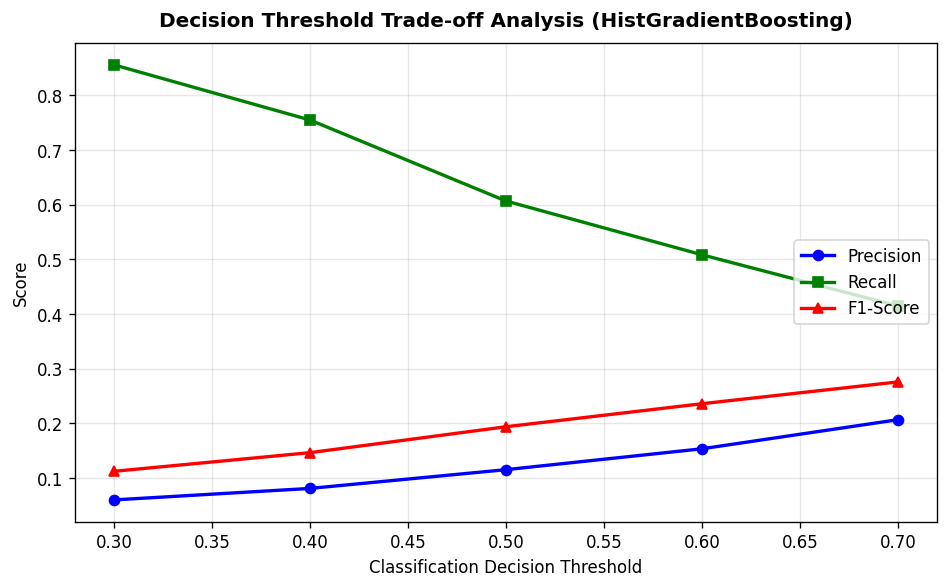

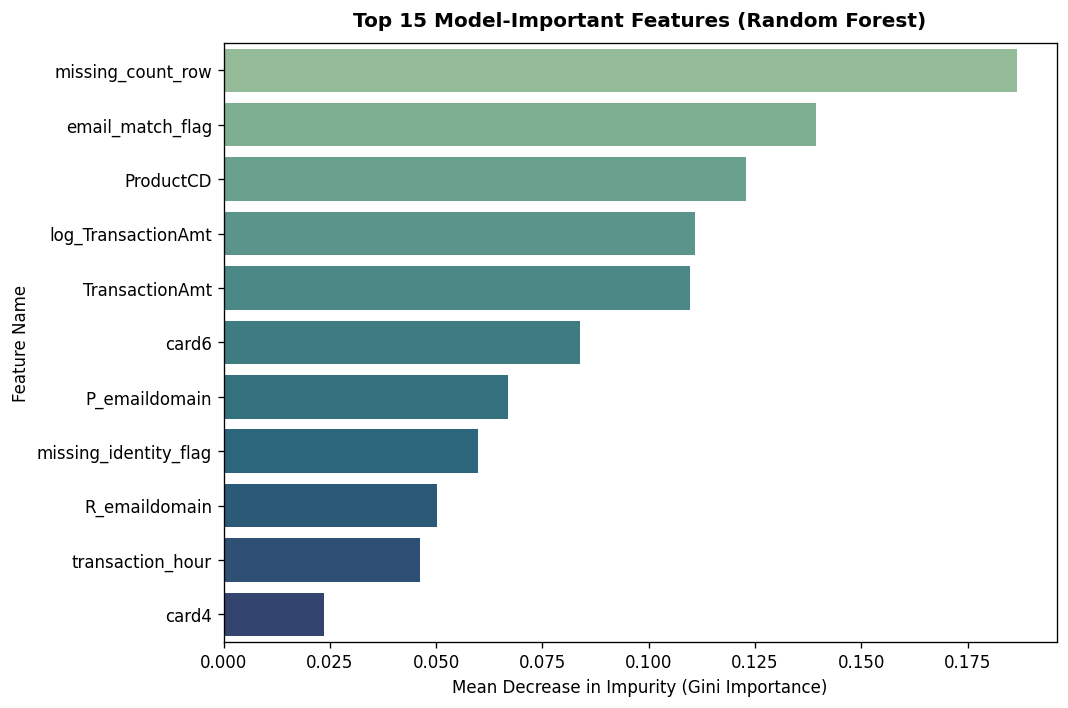

In [5]:
model_rows = comp_df[comp_df['Model'] != 'Majority-Class Baseline'].copy()
best_model_name = model_rows.loc[model_rows['PR-AUC'].idxmax(), 'Model']
best_prob = results[best_model_name]['y_prob']

print(f'Top Model Selected Dynamically by PR-AUC: {best_model_name}')
thresh_df = evaluate_thresholds(y_val, best_prob)
thresh_df.to_csv(os.path.join(tbl_dir, 'threshold_analysis.csv'), index=False)
print(thresh_df)

plot_threshold_tradeoff(thresh_df, best_model_name, os.path.join(fig_dir, 'threshold_tradeoff.png'))

rf_model = results['Random Forest']['model']
plot_feature_importance(rf_model.feature_importances_, feature_cols, os.path.join(fig_dir, 'feature_importance.png'))
imp_df = pd.DataFrame({'Feature': feature_cols, 'Gini_Importance': rf_model.feature_importances_}).sort_values(by='Gini_Importance', ascending=False)
print('=== RANDOM FOREST GINI FEATURE IMPORTANCE ===')
print(imp_df.to_string(index=False))


## 6. Final Sanity Check


In [6]:
print('=== FINAL SANITY CHECK ===')
print(f'Training rows:   {len(y_train):,}')
print(f'Validation rows: {len(y_val):,}')
print(f'Fraud in validation: {int(y_val.sum()):,}')
print(f'Legitimate in validation: {int((y_val == 0).sum()):,}')
print(f'Number of modeling features: {len(feature_cols)}')
print(f'Selected features: {feature_cols}')
print(f'Threshold-analysis model: {best_model_name}')

assert len(y_train) == len(X_train_model)
assert len(y_val) == len(X_val_model)
assert set(feature_cols).issubset(X_train.columns)
assert set(feature_cols).issubset(X_val.columns)
assert best_model_name in results

print('All final checks passed.')


=== FINAL SANITY CHECK ===
Training rows:   472,432
Validation rows: 118,108
Fraud in validation: 4,064
Legitimate in validation: 114,044
Number of modeling features: 11
Selected features: ['TransactionAmt', 'ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'transaction_hour', 'log_TransactionAmt', 'missing_identity_flag', 'missing_count_row', 'email_match_flag']
Threshold-analysis model: HistGradientBoosting
All final checks passed.
